# 06 - Double Poisson Models for 1X2 Prediction

This notebook implements the double Poisson framework for Bundesliga `1X2` prediction.
Instead of predicting the final class directly, it models home and away scoring intensities
and derives match-outcome probabilities from the implied score matrix.

## 1. Imports and Setup

In [3]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

PROJECT_ROOT = Path.cwd().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import PROCESSED_DATA_DIR, RAW_DATA_DIR
from src.data_builder import attach_fbref_match_metadata
from src.double_poisson import DoublePoissonRegressor, get_double_poisson_model_space, run_double_poisson_backtest, run_static_double_poisson_screening, fit_final_double_poisson_model, top_scorelines_from_matrix
from src.ml_modeling import score_predictions, build_class_metrics_table
from src.run_artifacts import save_run_artifacts, save_deployment_model
from src.rolling_backtest import evaluate_by_matchday, summarize_predictions


## 2. Load the Advanced Match Table

The double Poisson model uses the same advanced match table as the ML notebooks,
including matchday metadata for seasonal diagnostics.

In [4]:
features_path = PROCESSED_DATA_DIR / 'match_features_advanced.parquet'
if not features_path.exists():
    features_path = PROCESSED_DATA_DIR / 'match_features_advanced.csv'

try:
    df = pd.read_parquet(features_path) if features_path.suffix == '.parquet' else pd.read_csv(features_path)
except Exception:
    df = pd.read_csv(PROCESSED_DATA_DIR / 'match_features_advanced.csv')

df['date'] = pd.to_datetime(df['date'], errors='coerce')

if 'matchday' not in df.columns:
    fbref_schedule_path = RAW_DATA_DIR / 'fbref' / 'schedule.parquet'
    if not fbref_schedule_path.exists():
        fbref_schedule_path = RAW_DATA_DIR / 'fbref' / 'schedule.csv'

    try:
        fbref_schedule = pd.read_parquet(fbref_schedule_path) if fbref_schedule_path.suffix == '.parquet' else pd.read_csv(fbref_schedule_path)
    except Exception:
        fbref_schedule = pd.read_csv(RAW_DATA_DIR / 'fbref' / 'schedule.csv')

    df = attach_fbref_match_metadata(df, fbref_schedule)

preview_cols = [
    col for col in [
        'date', 'home_team', 'away_team', 'home_goals', 'away_goals', 'target_1x2', 'matchday'
    ]
    if col in df.columns
]

print('Dataset shape:', df.shape)
print(f"Matchday coverage: {df['matchday'].notna().mean():.1%}" if 'matchday' in df.columns else 'Matchday column unavailable')
display(df[preview_cols].head())


Dataset shape: (882, 252)
Matchday coverage: 85.1%


,date,home_team,away_team,home_goals,away_goals,target_1x2,matchday
0,2023-08-18 18:30:00,Werder Bremen,Bayern Munich,0,4,A,1
1,2023-08-19 13:30:00,Bayer Leverkusen,RasenBallsport Leipzig,3,2,H,1
2,2023-08-19 13:30:00,Wolfsburg,FC Heidenheim,2,0,H,1
3,2023-08-19 13:30:00,Hoffenheim,Freiburg,1,2,A,1
4,2023-08-19 13:30:00,Augsburg,Borussia M.Gladbach,4,4,D,1


## 3. Define the Modeling Objective

The multiclass target is `target_1x2`.
The double Poisson model first estimates `lambda_H` and `lambda_A`, then converts the score distribution into `H`, `D`, and `A` probabilities.

In [5]:
TARGET_COL = 'target_1x2'
RUN_KEY = 'double_poisson_multiclass'
TARGET_LABELS = ['H', 'D', 'A']
print('Average home goals:', round(df['home_goals'].mean(), 3))
print('Average away goals:', round(df['away_goals'].mean(), 3))

Average home goals: 1.73
Average away goals: 1.455


## 4. Define the Poisson Model Space and Static Screening

The model variants differ mainly in the strength of the ridge-like shrinkage applied to team attack and defense parameters.
This matters because the Bundesliga sample is moderate in size relative to the number of team-level coefficients.

In [6]:
POISSON_MODEL_SPACE = get_double_poisson_model_space()
POISSON_BACKTEST_CONFIG = {'test_season_id': 2025, 'min_train_size': 100}
poisson_screening = run_static_double_poisson_screening(
    df=df,
    model_space=POISSON_MODEL_SPACE,
    target_col=TARGET_COL,
    outcome_mode='1x2',
    primary_metric='accuracy',
)
display(poisson_screening)

,model,accuracy,macro_f1,weighted_f1,alpha,max_goals,avg_lambda_home,avg_lambda_away
0,double_poisson_alpha_0_1,0.438596,0.326544,0.350779,0.1,10,1.757967,1.483879
1,double_poisson_alpha_0_5,0.409357,0.288421,0.306696,0.5,10,1.698319,1.545303
2,double_poisson_alpha_2_0,0.391813,0.263688,0.278307,2.0,10,1.650423,1.592710
3,double_poisson_alpha_1_0,0.391813,0.263627,0.278082,1.0,10,1.671015,1.572322


## 5. Run the Rolling Backtests

Each kickoff batch is predicted only from the match history available before that date.
This preserves the same forecasting discipline as in the ML notebooks.

In [7]:
poisson_outputs = {}
for model_name, model_config in POISSON_MODEL_SPACE.items():
    print(f'Running {model_name}...')
    predictions, fit_summary = run_double_poisson_backtest(
        df=df,
        model_name=model_name,
        model_config=model_config,
        target_col=TARGET_COL,
        outcome_mode='1x2',
        **POISSON_BACKTEST_CONFIG,
    )
    results = summarize_predictions(predictions)
    poisson_outputs[model_name] = {
        'predictions': predictions,
        'fit_summary': fit_summary,
        'results': results,
        'config': model_config,
    }

all_predictions = pd.concat([payload['predictions'] for payload in poisson_outputs.values()], ignore_index=True)
all_fit_summaries = pd.concat([payload['fit_summary'] for payload in poisson_outputs.values()], ignore_index=True)
all_model_results = pd.concat([payload['results'] for payload in poisson_outputs.values()], ignore_index=True).sort_values(['accuracy', 'macro_f1'], ascending=False).reset_index(drop=True)
all_model_results

Running double_poisson_alpha_0_1...
Running double_poisson_alpha_0_5...
Running double_poisson_alpha_1_0...
Running double_poisson_alpha_2_0...


,model,accuracy,macro_f1,weighted_f1
0,double_poisson_alpha_0_1,0.555556,0.403330,0.467522
1,double_poisson_alpha_0_5,0.514815,0.361197,0.422833
2,double_poisson_alpha_1_0,0.511111,0.354028,0.415390
3,double_poisson_alpha_2_0,0.503704,0.340131,0.401856


## 6. Fit Diagnostics Across Batches

In [8]:
fit_diagnostics = (
    all_fit_summaries.groupby('model')
    .agg(
        mean_intercept_log_rate=('intercept_log_rate', 'mean'),
        mean_home_advantage=('home_advantage_log_effect', 'mean'),
        n_batches=('batch_id', 'nunique'),
        mean_history_size=('n_history_matches', 'mean'),
    )
    .reset_index()
    .merge(all_model_results[['model', 'accuracy', 'macro_f1']], on='model', how='left')
)
fit_diagnostics.sort_values(['accuracy', 'mean_home_advantage'], ascending=[False, False])

,model,mean_intercept_log_rate,mean_home_advantage,n_batches,mean_history_size,accuracy,macro_f1
0,double_poisson_alpha_0_1,0.377470,0.134556,164,747.060976,0.555556,0.403330
1,double_poisson_alpha_0_5,0.424242,0.074567,164,747.060976,0.514815,0.361197
2,double_poisson_alpha_1_0,0.439576,0.047903,164,747.060976,0.511111,0.354028
3,double_poisson_alpha_2_0,0.450375,0.027937,164,747.060976,0.503704,0.340131


## 7. Accuracy by Bundesliga Matchday

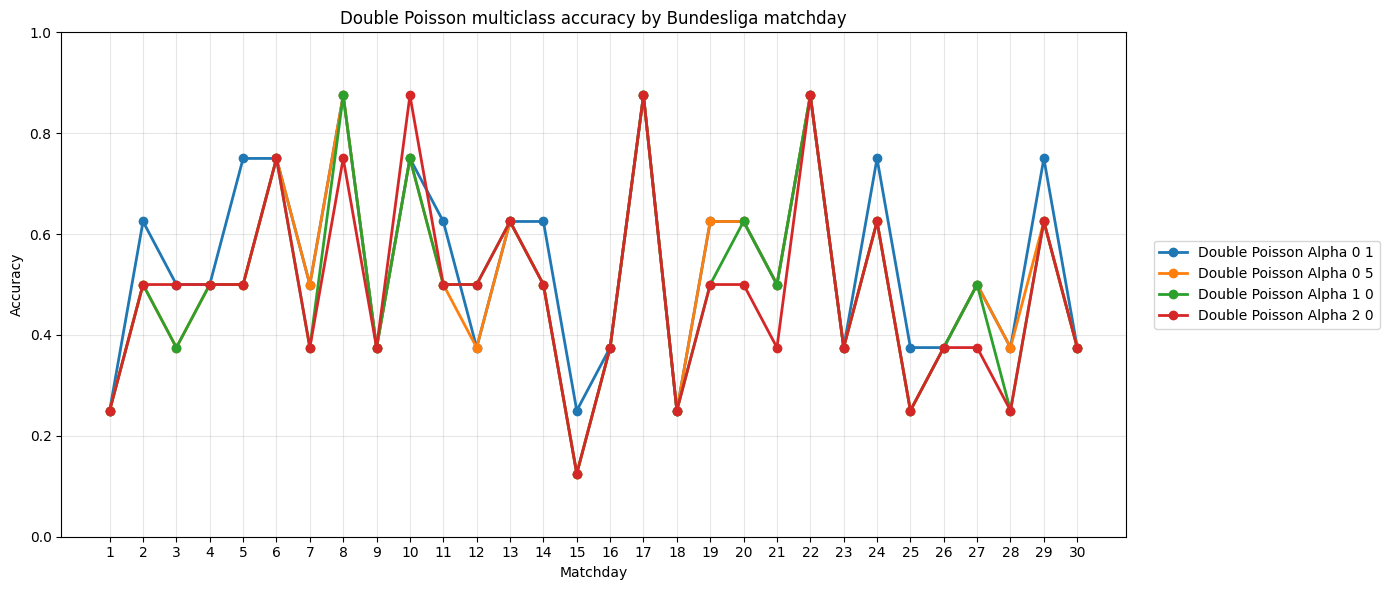

,model,matchday,n_matches,accuracy,macro_f1,weighted_f1
0,double_poisson_alpha_0_1,1,8,0.250,0.133333,0.150000
1,double_poisson_alpha_0_1,2,8,0.625,0.472222,0.531250
2,double_poisson_alpha_0_1,3,8,0.500,0.333333,0.450000
3,double_poisson_alpha_0_1,4,8,0.500,0.333333,0.425000
4,double_poisson_alpha_0_1,5,8,0.750,0.555556,0.666667
...,...,...,...,...,...,...
115,double_poisson_alpha_2_0,26,8,0.375,0.181818,0.204545
116,double_poisson_alpha_2_0,27,8,0.375,0.200000,0.225000
117,double_poisson_alpha_2_0,28,8,0.250,0.250000,0.218750
118,double_poisson_alpha_2_0,29,8,0.625,0.409091,0.551136


In [9]:
accuracy_by_matchday = evaluate_by_matchday(all_predictions)
fig, ax = plt.subplots(figsize=(14, 6))
for model_name, group in accuracy_by_matchday.groupby('model'):
    ax.plot(group['matchday'], group['accuracy'], marker='o', linewidth=2, label=model_name.replace('_', ' ').title())
ax.set_title('Double Poisson multiclass accuracy by Bundesliga matchday')
ax.set_xlabel('Matchday')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.set_xticks(sorted(accuracy_by_matchday['matchday'].dropna().unique()))
ax.grid(alpha=0.3)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()
accuracy_by_matchday

## 8. Best-Model Diagnostics

In [10]:
best_model_name = all_model_results.iloc[0]['model']
best_payload = poisson_outputs[best_model_name]
best_predictions = best_payload['predictions'].copy()
best_fit_summary = best_payload['fit_summary'].copy()
best_metrics = score_predictions(best_predictions['target'], best_predictions['y_pred'])
best_class_metrics = build_class_metrics_table(best_metrics['classification_report_dict'])

print('Best model:', best_model_name)
display(all_model_results[all_model_results['model'] == best_model_name])
display(best_fit_summary.head())
display(best_class_metrics)

Best model: double_poisson_alpha_0_1


,model,accuracy,macro_f1,weighted_f1
0,double_poisson_alpha_0_1,0.555556,0.40333,0.467522


,batch_id,kickoff_time,model,n_history_matches,alpha,max_goals,intercept_log_rate,home_advantage_log_effect
0,1,2025-08-22 18:30:00,double_poisson_alpha_0_1,612,0.1,10,0.375459,0.133373
1,2,2025-08-23 13:30:00,double_poisson_alpha_0_1,613,0.1,10,0.374219,0.137474
2,3,2025-08-23 16:30:00,double_poisson_alpha_0_1,618,0.1,10,0.377417,0.135070
3,4,2025-08-24 13:30:00,double_poisson_alpha_0_1,619,0.1,10,0.379475,0.135012
4,5,2025-08-24 15:30:00,double_poisson_alpha_0_1,620,0.1,10,0.378930,0.133905


,class,precision,recall,f1_score,support
0,A,0.569444,0.482353,0.522293,85.0
1,D,0.000000,0.000000,0.000000,66.0
2,H,0.550505,0.915966,0.687697,119.0


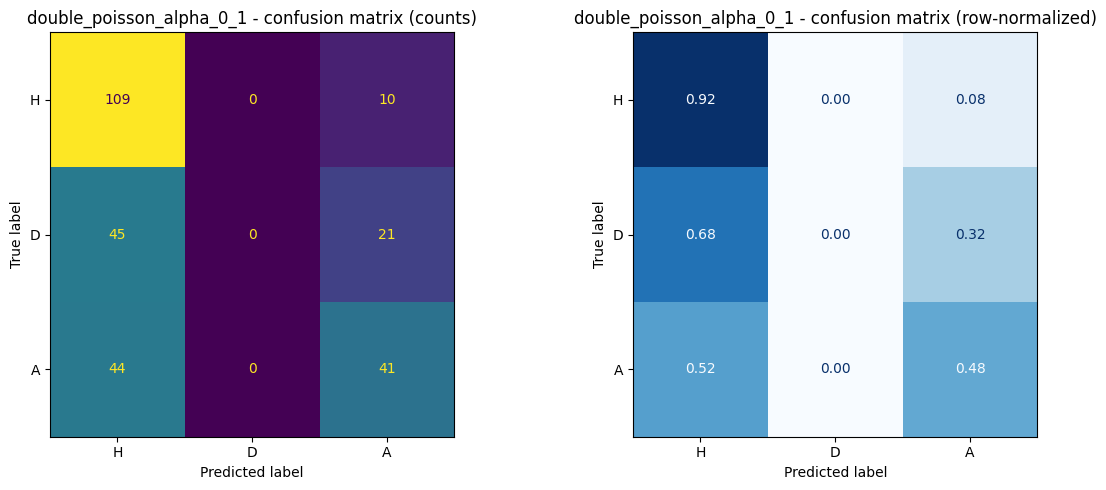

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(best_predictions['target'], best_predictions['y_pred'], labels=TARGET_LABELS), display_labels=TARGET_LABELS).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'{best_model_name} - confusion matrix (counts)')
ConfusionMatrixDisplay(confusion_matrix(best_predictions['target'], best_predictions['y_pred'], labels=TARGET_LABELS, normalize='true'), display_labels=TARGET_LABELS).plot(ax=axes[1], cmap='Blues', colorbar=False, values_format='.2f')
axes[1].set_title(f'{best_model_name} - confusion matrix (row-normalized)')
plt.tight_layout()
plt.show()

In [12]:
best_errors = best_predictions.loc[
    best_predictions['target'] != best_predictions['y_pred'],
    ['matchday', 'date', 'home_team', 'away_team', 'target', 'y_pred', 'home_win_prob', 'draw_prob', 'away_win_prob', 'predicted_home_goals', 'predicted_away_goals'],
].copy()
best_errors['error_type'] = best_errors['target'].astype(str) + ' -> ' + best_errors['y_pred'].astype(str)
error_breakdown = best_errors['error_type'].value_counts().rename_axis('error_type').to_frame('count')
display(error_breakdown)
display(best_errors.head(15))

,count
error_type,
D -> H,45
A -> H,44
D -> A,21
H -> A,10


,matchday,date,home_team,away_team,target,y_pred,home_win_prob,draw_prob,away_win_prob,predicted_home_goals,predicted_away_goals,error_type
1,1,2025-08-23 13:30:00,FC Heidenheim,Wolfsburg,A,H,0.397220,0.242632,0.360148,1,1,A -> H
2,1,2025-08-23 13:30:00,Bayer Leverkusen,Hoffenheim,A,H,0.613858,0.191684,0.194458,2,1,A -> H
3,1,2025-08-23 13:30:00,Union Berlin,VfB Stuttgart,H,A,0.301368,0.238870,0.459763,1,1,H -> A
5,1,2025-08-23 13:30:00,Freiburg,Augsburg,A,H,0.435494,0.243861,0.320645,1,1,A -> H
6,<NA>,2025-08-23 16:30:00,St. Pauli,Borussia Dortmund,D,A,0.335336,0.246315,0.418349,1,1,D -> A
7,1,2025-08-24 13:30:00,Mainz 05,FC Cologne,A,H,0.478047,0.245089,0.276864,1,1,A -> H
8,1,2025-08-24 15:30:00,Borussia M.Gladbach,Hamburger SV,D,H,0.416522,0.230863,0.352616,1,1,D -> H
9,2,2025-08-29 18:30:00,Hamburger SV,St. Pauli,A,H,0.437321,0.250603,0.312075,1,1,A -> H
12,2,2025-08-30 13:30:00,Werder Bremen,Bayer Leverkusen,D,A,0.285864,0.226926,0.487209,1,1,D -> A
15,2,2025-08-31 13:30:00,Wolfsburg,Mainz 05,D,H,0.405728,0.247881,0.346391,1,1,D -> H


## 9. Score-Matrix Diagnostic for One Match

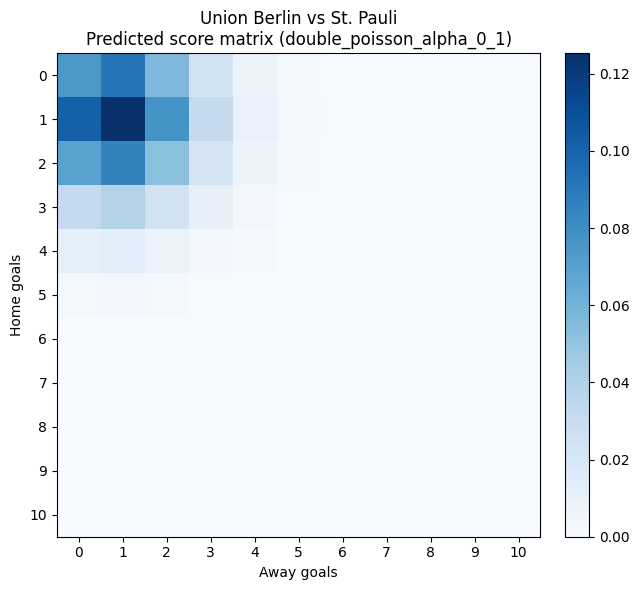

,date,home_team,away_team,home_goals,away_goals,target_1x2
862,2026-04-05 13:30:00,Union Berlin,St. Pauli,1,1,D


,pred_home_goals,pred_away_goals,probability
0,1,1,0.125332
1,1,0,0.101706
2,0,1,0.091938
3,2,1,0.085428
4,1,2,0.077223
5,0,0,0.074607
6,2,0,0.069324
7,0,2,0.056648
8,2,2,0.052636
9,3,1,0.038819


In [13]:
example_match = best_predictions.sort_values('predicted_score_prob', ascending=False).iloc[0]
example_match_df = df[df['game_id'] == example_match['game_id']].copy()
example_history = df[df['date'] < pd.to_datetime(example_match['date'])].copy()
example_model = DoublePoissonRegressor(**POISSON_MODEL_SPACE[best_model_name]).fit(example_history)
example_score_matrix = example_model.predict_score_matrix(example_match_df)
example_top_scorelines = top_scorelines_from_matrix(example_score_matrix, top_n=10)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(example_score_matrix, cmap='Blues')
ax.set_title(
    f"{example_match['home_team']} vs {example_match['away_team']}\n"
    f"Predicted score matrix ({best_model_name})"
)
ax.set_xlabel('Away goals')
ax.set_ylabel('Home goals')
ax.set_xticks(range(example_score_matrix.shape[1]))
ax.set_yticks(range(example_score_matrix.shape[0]))
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

display(example_match_df[['date', 'home_team', 'away_team', 'home_goals', 'away_goals', 'target_1x2']])
display(example_top_scorelines)


## 10. Save Run Outputs and Persist the Deployment Model

In [14]:
final_fit = fit_final_double_poisson_model(
    df=df,
    model_name=best_model_name,
    model_config=POISSON_MODEL_SPACE[best_model_name],
    target_col=TARGET_COL,
)

run_metadata = {
    'run_key': RUN_KEY,
    'target_col': TARGET_COL,
    'task_type': 'multiclass_double_poisson',
    'test_season_id': POISSON_BACKTEST_CONFIG['test_season_id'],
    'model_space': POISSON_MODEL_SPACE,
    'best_model_name': best_model_name,
    'deployment_fit_summary': final_fit['fit_summary'],
}

run_dir = save_run_artifacts(
    run_key=RUN_KEY,
    metadata=run_metadata,
    tables={
        'poisson_screening': poisson_screening,
        'all_model_results': all_model_results,
        'all_predictions': all_predictions,
        'all_fit_summaries': all_fit_summaries,
        'fit_diagnostics': fit_diagnostics,
        'accuracy_by_matchday': accuracy_by_matchday,
        'best_model_predictions': best_predictions,
        'best_model_class_metrics': best_class_metrics,
        'best_model_team_strengths': final_fit['team_strengths'],
    },
)

artifact_path = save_deployment_model(
    run_key=RUN_KEY,
    artifact_name='best_model',
    model_object={
        'estimator': final_fit['estimator'],
        'target_col': TARGET_COL,
        'model_name': best_model_name,
    },
    metadata={
        'run_key': RUN_KEY,
        'best_model_name': best_model_name,
        'fit_summary': final_fit['fit_summary'],
    },
)

print('Saved run outputs to:', run_dir)
print('Saved deployment artifact to:', artifact_path)

Saved run outputs to: C:\Users\cerve\Desktop\DP\match_prediction\data\processed\model_runs\double_poisson_multiclass
Saved deployment artifact to: C:\Users\cerve\Desktop\DP\match_prediction\outputs\models\deployment\double_poisson_multiclass\best_model.pkl
